In [2]:
!pip install rdkit pandas scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 39.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/dataprofessor/data/master/delaney_solubility_with_descriptors.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (1144, 5)

Columns:
['MolLogP', 'MolWt', 'NumRotatableBonds', 'AromaticProportion', 'logS']


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
MolLogP               0
MolWt                 0
NumRotatableBonds     0
AromaticProportion    0
logS                  0
dtype: int64


In [6]:
X = df.drop("logS", axis=1)

y = df["logS"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1144, 4)
Target Shape: (1144,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (915, 4)
Testing Set : (229, 4)


In [8]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [11]:
y_pred = model.predict(X_test)

print("Number of Predictions:", len(y_pred))

Number of Predictions: 229


In [12]:
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score :", round(r2, 4))
print("RMSE      :", round(rmse, 4))

R² Score : 0.8875
RMSE      : 0.7


In [13]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

importance_df.to_csv(
    "Feature_Importance.csv",
    index=False
)

              Feature  Importance
0             MolLogP    0.828094
1               MolWt    0.129625
3  AromaticProportion    0.021991
2   NumRotatableBonds    0.020289


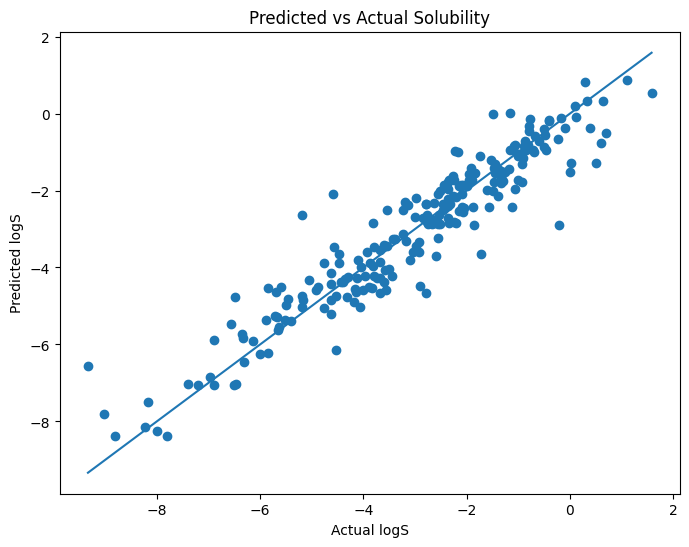

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual logS")
plt.ylabel("Predicted logS")
plt.title("Predicted vs Actual Solubility")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.savefig(
    "Predicted_vs_Actual.png",
    bbox_inches="tight"
)

plt.show()

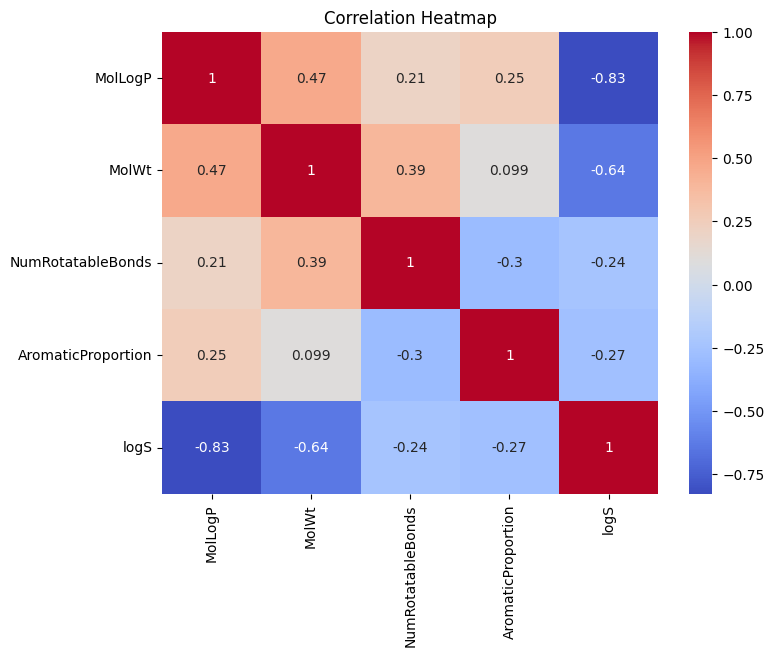

In [15]:
plt.figure(figsize=(8,6))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "Correlation_Heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [16]:
results_df = pd.DataFrame({
    "Actual_logS": y_test,
    "Predicted_logS": y_pred
})

results_df.to_csv(
    "Prediction_Results.csv",
    index=False
)

print(results_df.shape)

(229, 2)


In [17]:
performance_df = pd.DataFrame({
    "Metric": ["R2_Score", "RMSE"],
    "Value": [r2, rmse]
})

performance_df.to_csv(
    "Model_Performance.csv",
    index=False
)

print(performance_df)

     Metric     Value
0  R2_Score  0.887460
1      RMSE  0.700042
